In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
house_prices = pd.read_csv('./House_Price_dataset.csv',sep=',')

In [3]:
house_prices

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4.0,2.0,3.0,yes,no,no,no,yes,2.0,yes,furnished
1,12250000,8960,4.0,4.0,4.0,yes,no,no,no,yes,3.0,no,furnished
2,12250000,9960,3.0,2.0,2.0,yes,no,yes,no,no,2.0,yes,semi-furnished
3,12215000,7500,4.0,2.0,2.0,yes,no,yes,no,yes,3.0,yes,furnished
4,11410000,7420,4.0,1.0,2.0,yes,yes,yes,no,yes,2.0,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2.0,1.0,1.0,yes,no,yes,no,no,2.0,no,unfurnished
541,1767150,2400,3.0,1.0,1.0,no,no,no,no,no,0.0,no,semi-furnished
542,1750000,3620,2.0,1.0,1.0,yes,no,no,no,no,0.0,no,unfurnished
543,1750000,2910,3.0,1.0,1.0,no,no,no,no,no,0.0,no,furnished


In [4]:
house_prices.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,540.000000,540.000000,543.000000,541.000000
mean,4.766729e+06,5150.541284,2.961111,1.285185,1.804788,0.691312
std,1.870440e+06,2170.141023,0.738779,0.502464,0.869011,0.860070
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
(house_prices.isnull()).sum()

price               0
area                0
bedrooms            5
bathrooms           5
stories             2
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             4
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
(house_prices.select_dtypes(include=['int64','float64'])).median()

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64

In [7]:
house_prices.select_dtypes(include=['int64','float64']).mean()

price        4.766729e+06
area         5.150541e+03
bedrooms     2.961111e+00
bathrooms    1.285185e+00
stories      1.804788e+00
parking      6.913124e-01
dtype: float64

In [8]:
house_prices.mode()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,3500000,6000.0,3.0,1.0,2.0,yes,no,no,no,no,0.0,no,semi-furnished
1,4200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
house_prices=house_prices.fillna((house_prices.select_dtypes(include=['int64','float64'])).median())

In [10]:
(house_prices.isnull()).sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
x = house_prices[['area']]
y = house_prices[['price']]

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=69)


In [13]:
priceModel = LinearRegression().fit(x_train,y_train)

In [14]:
priceModel.coef_

array([[420.83286393]])

In [15]:
y_tpred = priceModel.predict(x_train)

In [16]:
train_mse = mean_squared_error(y_train,y_tpred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train,y_tpred)
print("Mean squared error",train_mse,"\nRMSE",train_rmse,"\nR^2 Score",train_r2)

Mean squared error 2231722397483.0713 
RMSE 1493895.0423249523 
R^2 Score 0.27316451038299494


In [17]:
y_pred = priceModel.predict(x_test)

In [18]:
test_mse = mean_squared_error(y_test,y_pred)
test_rmse = ((test_mse)**0.5)
test_r2 = r2_score(y_test,y_pred)
print("Mean squared error",train_mse,"\nRMSE",train_rmse,"\nR^2 Score",train_r2)

Mean squared error 2231722397483.0713 
RMSE 1493895.0423249523 
R^2 Score 0.27316451038299494


<Axes: xlabel='area', ylabel='price'>

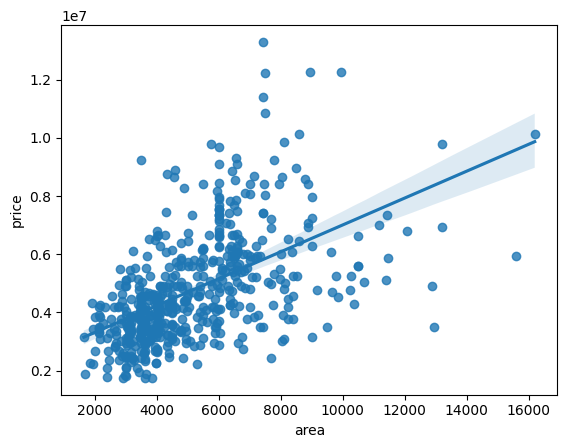

In [19]:
sns.regplot(x="area",y="price",data=house_prices)

In [20]:
x2 = house_prices.drop(columns=['price'])
x2 = x2.replace({'yes': 1, 'no': 0})
x2 = x2.replace({'furnished': 2, 'semi-furnished': 1,'unfurnished':0})

C:\Users\AR\AppData\Local\Temp\ipykernel_5432\1427114761.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x2 = x2.replace({'yes': 1, 'no': 0})
C:\Users\AR\AppData\Local\Temp\ipykernel_5432\1427114761.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x2 = x2.replace({'furnished': 2, 'semi-furnished': 1,'unfurnished':0})


In [36]:
x2_train,x2_test,y_train,y_test = train_test_split(x2,y,test_size=0.2,random_state=69,shuffle=True)

In [37]:
betterPriceModel = LinearRegression().fit(x2_train,y_train)

In [38]:
y2t_pred=betterPriceModel.predict(x2_train)

In [39]:
train2_mse = mean_squared_error(y_train,y2t_pred)
train2_rmse = np.sqrt(train2_mse)
train2_r2 = r2_score(y_train,y2t_pred)
print("Mean squared error",train2_mse,"\nRMSE",train2_rmse,"\nR^2 Score",train2_r2)

Mean squared error 929876968560.7394 
RMSE 964301.2851597469 
R^2 Score 0.6971542775706949


In [40]:
x2_test = x2_test[x2_train.columns]

y2_pred=betterPriceModel.predict(x2_test)

In [42]:
test2_mse = mean_squared_error(y_test,y2_pred)
test2_rmse = np.sqrt(test2_mse)
test2_r2 = r2_score(y_test,y2_pred)
print("Mean squared error",test2_mse,"\nRMSE",test2_rmse,"\nR^2 Score",test2_r2)

Mean squared error 2032257490178.0037 
RMSE 1425572.6884932958 
R^2 Score 0.595224504692778
